# **Problem Statement**
Porter is India's largest intra-city logistics marketplace, handling delivery of goods, especially food, from restaurants to customers. The company has a large pool of delivery partners and wants to estimate delivery times for orders using historical data. This is important because:

Customers want accurate delivery time estimates.

Efficient allocation of delivery partners can reduce delays and optimize operations.

Insights can improve driver earnings and customer satisfaction.

Goal:

Building a regression model that predict the estimated delivery time for food orders in Porter's intra-city logistics network. Using historical delivery data, the model will estimate the time from order placement to actual delivery based on features like order details (e.g., items, prices), restaurant category, market, order protocol, partner availability, and estimated driving duration. Accurate predictions help set customer expectations, optimize partner allocation, and improve service reliability.

This approach can be used in e-commerce/logistics platforms (e.g., Uber Eats, DoorDash) for real-time ETA forecasting. Modifications could extend to multi-modal transport (e.g., incorporating traffic APIs for dynamic ETAs) or predictive maintenance for delivery vehicles.

Dataset Overview

Each row represents one delivery. Key columns:

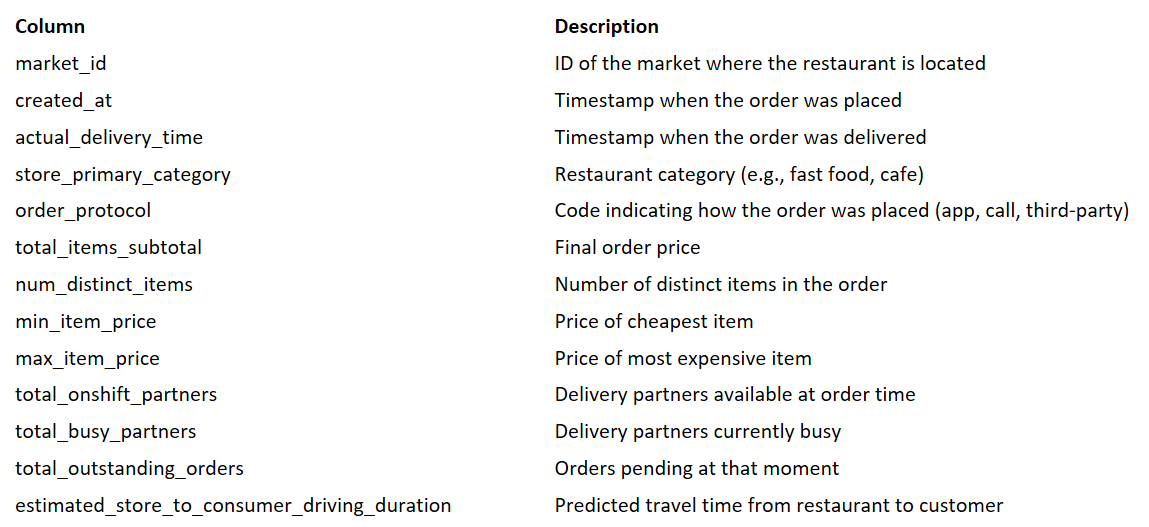

In [55]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import LocalOutlierFactor
from sklearn.impute import KNNImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, LeakyReLU, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.utils import plot_model

from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

In [6]:
# Data Loading

df=pd.read_csv('data_2.csv')
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1,06-02-2015 22:24,06-02-2015 23:11,4,1,4,3441,4,557,1239,33,14,21,861
1,2,10-02-2015 21:49,10-02-2015 22:33,46,2,1,1900,1,1400,1400,1,2,2,690
2,2,16-02-2015 00:11,16-02-2015 01:06,36,3,4,4771,3,820,1604,8,6,18,289
3,1,12-02-2015 03:36,12-02-2015 04:35,38,1,1,1525,1,1525,1525,5,6,8,795
4,1,27-01-2015 02:12,27-01-2015 02:58,38,1,2,3620,2,1425,2195,5,5,7,205


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype 
---  ------                                        --------------   ----- 
 0   market_id                                     175777 non-null  int64 
 1   created_at                                    175777 non-null  object
 2   actual_delivery_time                          175777 non-null  object
 3   store_primary_category                        175777 non-null  int64 
 4   order_protocol                                175777 non-null  int64 
 5   total_items                                   175777 non-null  int64 
 6   subtotal                                      175777 non-null  int64 
 7   num_distinct_items                            175777 non-null  int64 
 8   min_item_price                                175777 non-null  int64 
 9   max_item_price                                175777 non-nu

The dataset contains 175,777 rows and 14 columns, meaning there are 175,777 delivery records.

There are 12 numerical columns (int64) and 2 object columns.

The columns created_at and actual_delivery_time are stored as object data type, which indicates they are timestamps stored as strings.

These should be converted to datetime format for further analysis and feature engineering.

All columns have 175,777 non-null values, which indicates that there are no missing values in the dataset.

Several features relate to:

Order characteristics (total_items, subtotal, num_distinct_items)

Pricing information (min_item_price, max_item_price)

Delivery partner availability (total_onshift_dashers, total_busy_dashers)

System workload (total_outstanding_orders)

Travel time estimate (estimated_store_to_consumer_driving_duration)

The memory usage of the dataset is 18.8 MB, which is manageable for analysis and model training.

In [8]:
df.isna().sum()

,0
market_id,0
created_at,0
actual_delivery_time,0
store_primary_category,0
order_protocol,0
total_items,0
subtotal,0
num_distinct_items,0
min_item_price,0
max_item_price,0


The missing value check shows that all columns contain 0 null values.

This means the dataset is complete and does not contain any missing data.

Since there are no null values, no imputation techniques such as mean/median filling or KNN imputation are required at this stage.

All 175,777 records can be used for analysis and model training without dropping any rows due to missing values.

In [9]:
df.nunique()

,0
market_id,6
created_at,23362
actual_delivery_time,23420
store_primary_category,73
order_protocol,7
total_items,54
subtotal,8182
num_distinct_items,20
min_item_price,2251
max_item_price,2585


The df.nunique() function was used to determine the number of unique values in each column.

The market_id column has only 6 unique values, indicating the dataset contains orders from six different markets.

The timestamp columns (created_at and actual_delivery_time) have a very high number of unique values, which is expected since each order occurs at a different time.

The store_primary_category column has 73 unique categories, representing different types of restaurants.

The order_protocol column has 7 unique values, indicating the order can be placed through several different ordering methods.

Order-related features such as total_items, subtotal, and num_distinct_items have multiple unique values representing different order sizes and costs.

Delivery partner availability features like total_onshift_dashers, total_busy_dashers, and total_outstanding_orders also show a wide range of values, indicating varying system load conditions.

The estimated_store_to_consumer_driving_duration column has 1318 unique values, representing different estimated travel times between restaurants and customers.

The dataset contains a mix of categorical and numerical features. Columns like market_id, store_primary_category, and order_protocol have limited unique values and represent categorical variables, while order and delivery-related features have a larger range of unique values representing different operational conditions.

In [10]:
df.duplicated().value_counts()

,count
False,175776
True,1


Interpretation

175,776 rows are unique

1 row is duplicated

In [13]:
# Removing the duplicate record
df = df.drop_duplicates()

In [18]:
# After removing duplicates
df.duplicated().sum()

np.int64(0)

Duplicate records were checked using df.duplicated(). It was found that the dataset contained 1 duplicate row. This duplicate entry was removed using drop_duplicates() to maintain data integrity and ensure that each delivery record appears only once in the dataset.

In [19]:
df.head(5)

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_store_to_consumer_driving_duration
0,1,06-02-2015 22:24,06-02-2015 23:11,4,1,4,3441,4,557,1239,33,14,21,861
1,2,10-02-2015 21:49,10-02-2015 22:33,46,2,1,1900,1,1400,1400,1,2,2,690
2,2,16-02-2015 00:11,16-02-2015 01:06,36,3,4,4771,3,820,1604,8,6,18,289
3,1,12-02-2015 03:36,12-02-2015 04:35,38,1,1,1525,1,1525,1525,5,6,8,795
4,1,27-01-2015 02:12,27-01-2015 02:58,38,1,2,3620,2,1425,2195,5,5,7,205


In [21]:
# Creating Target Column

df['created_at'] = pd.to_datetime(df['created_at'], format='%d-%m-%Y %H:%M')
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'], format='%d-%m-%Y %H:%M')

In [22]:
# Delivery Time Calculation

df['Time_taken_for_delivery'] = (df['actual_delivery_time'] - df['created_at']) / pd.Timedelta('60s')

In [23]:
df['hour'] = df['created_at'].dt.hour
df['day'] = df['created_at'].dt.day
df['month'] = df['created_at'].dt.month

In [24]:
# Dropping the Column that are no longer required

df.drop(['created_at','actual_delivery_time'], axis=1, inplace=True)

In [25]:
# Encoding store_primary_category

df['store_primary_category'] = df['store_primary_category'].astype('category').cat.codes

The timestamp columns were converted to datetime format and used to create a new target variable representing delivery time in minutes. Additional temporal features such as order hour and day of the week were extracted to capture time-based delivery patterns. After feature extraction, the original timestamp columns were removed. The store_primary_category column was encoded into numerical category codes to make it suitable for machine learning models.

In [29]:
df.columns

Index(['market_id', 'store_primary_category', 'order_protocol', 'total_items',
       'subtotal', 'num_distinct_items', 'min_item_price', 'max_item_price',
       'total_onshift_dashers', 'total_busy_dashers',
       'total_outstanding_orders',
       'estimated_store_to_consumer_driving_duration',
       'Time_taken_for_delivery', 'hour', 'day', 'month'],
      dtype='object')

# **Correlation Analysis**

Why we do this:

To understand relationships between numeric features in the dataset.

To identify which features are highly correlated with the target (Time_taken_for_delivery), which are likely the most important for prediction.

To detect multicollinearity (features highly correlated with each other) that may affect some models.

To get insights for feature selection or feature engineering before modeling.

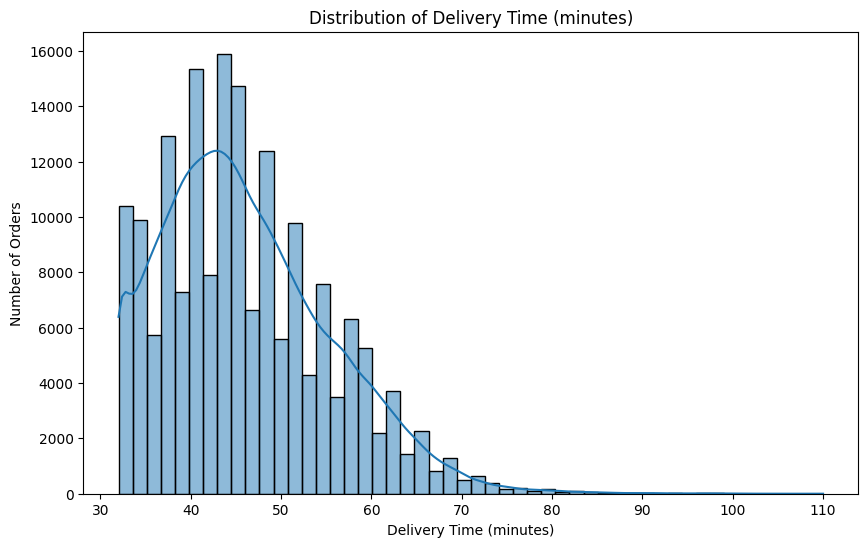

In [30]:
# Plot histogram of delivery time

plt.figure(figsize=(10,6))
sns.histplot(df['Time_taken_for_delivery'], bins=50, kde=True)
plt.title('Distribution of Delivery Time (minutes)')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Number of Orders')
plt.show()

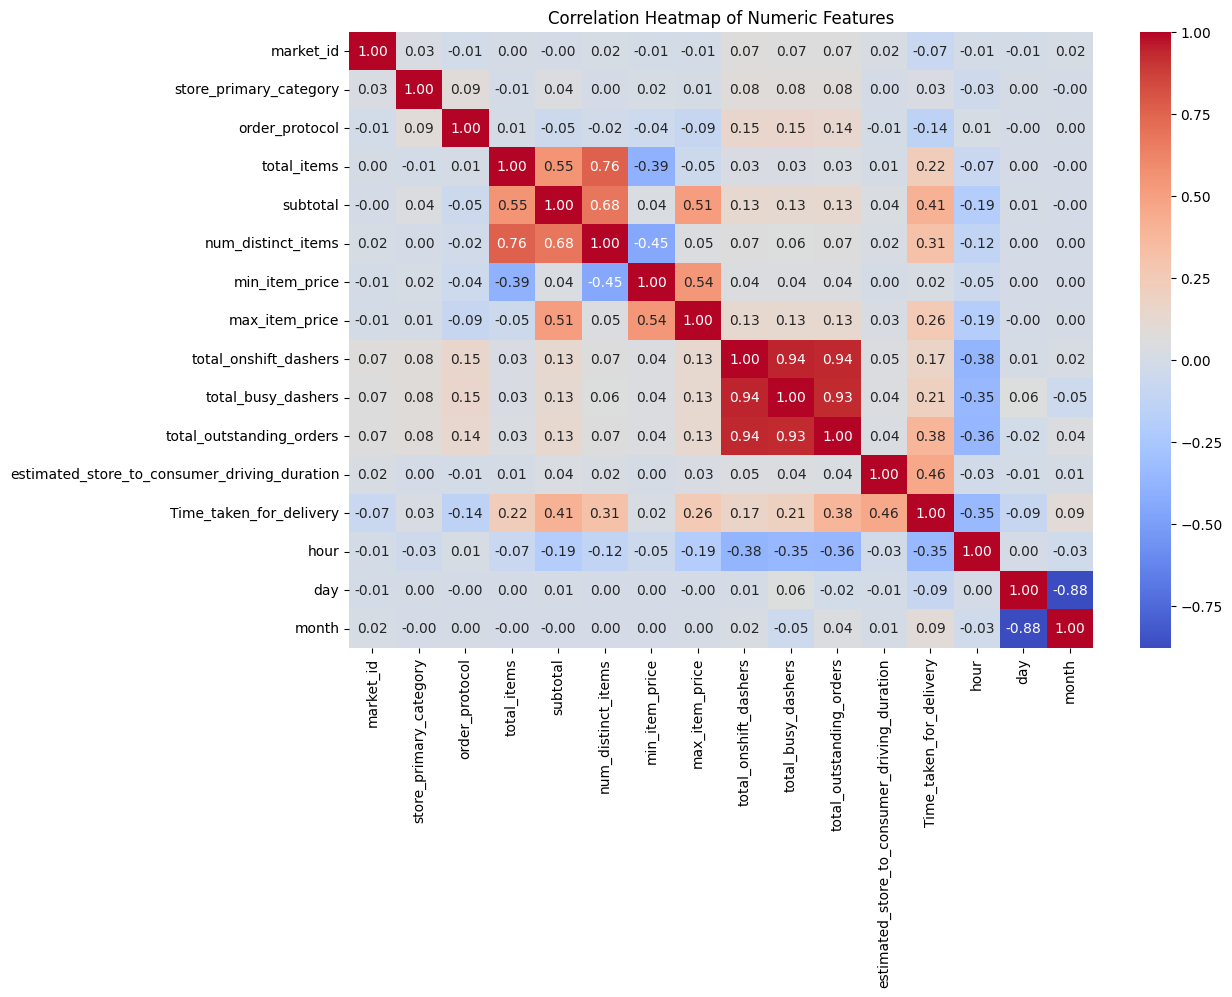

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [32]:
df.corr()['Time_taken_for_delivery'].sort_values(ascending=False)

,Time_taken_for_delivery
Time_taken_for_delivery,1.000000
estimated_store_to_consumer_driving_duration,0.460178
subtotal,0.413293
total_outstanding_orders,0.384981
num_distinct_items,0.312078
max_item_price,0.255194
total_items,0.224874
total_busy_dashers,0.206032
total_onshift_dashers,0.171004
month,0.091507


We computed the correlation of numeric features with the target Time_taken_for_delivery to identify which factors most influence delivery time. Features like estimated_store_to_consumer_driving_duration and subtotal are positively correlated, meaning higher values tend to increase delivery time. Features like hour are negatively correlated, indicating faster deliveries at certain times of day.

**Correlation of Features with Delivery Time**

The correlation of each numeric feature with the target variable Time_taken_for_delivery provides insights into which factors most strongly influence delivery time:

**Strong Positive Correlations**

estimated_store_to_consumer_driving_duration (0.46) → Longer driving distances naturally lead to longer delivery times.

subtotal (0.41) → Orders with higher subtotal (likely larger or more complex orders) tend to take more time.

total_outstanding_orders (0.38) → When there are more pending orders, delivery time increases due to higher workload.

num_distinct_items (0.31) → Orders with more unique items take longer to prepare and deliver.

**Moderate Positive Correlations**

max_item_price (0.25) and total_items (0.22) → Expensive or larger orders require slightly more time.

total_busy_dashers (0.21) and total_onshift_dashers (0.17) → More busy/on-shift delivery partners slightly affect delivery efficiency.

**Weak Positive Correlations**

month (0.09), store_primary_category (0.03), min_item_price (0.02) → Minimal effect on delivery time.

**Negative Correlations**

hour (-0.35) → Certain hours (likely non-rush hours) have faster deliveries.

order_protocol (-0.14), day (-0.08), market_id (-0.07) →   These features show a small inverse relationship; for example, some order methods or markets may handle deliveries more efficiently.

**Key Insights**

Distance and workload matter most: estimated_store_to_consumer_driving_duration and total_outstanding_orders are the top contributors.

Order complexity also affects time: subtotal and num_distinct_items indicate larger/more complex orders take longer.

Time-of-day effect: Negative correlation with hour suggests that rush hours significantly impact delivery times.

Other features like store category or market_id have minimal direct impact but may still provide minor contextual information.

# **Feature Analysis**

What are we going to do:
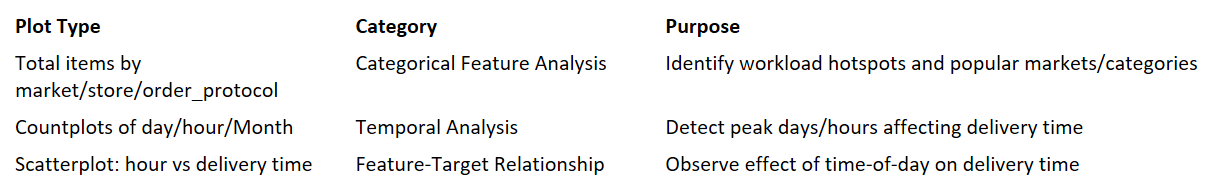

<Axes: xlabel='store_primary_category', ylabel='total_items'>

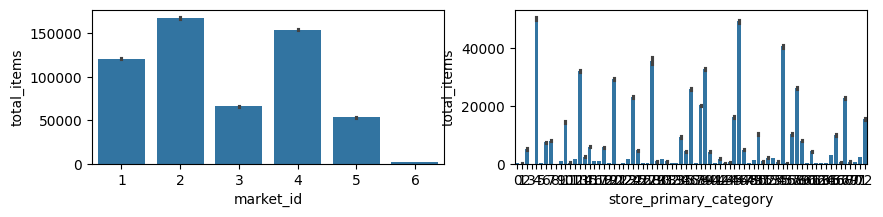

In [33]:
# Order Volume by Market and Restaurant Category

plt.figure(figsize=(10,2))
plt.subplot(1,2,1)
sns.barplot(y='total_items',x='market_id',data=df,estimator='sum')
plt.subplot(1,2,2)
sns.barplot(y='total_items',x='store_primary_category',data=df,estimator='sum')

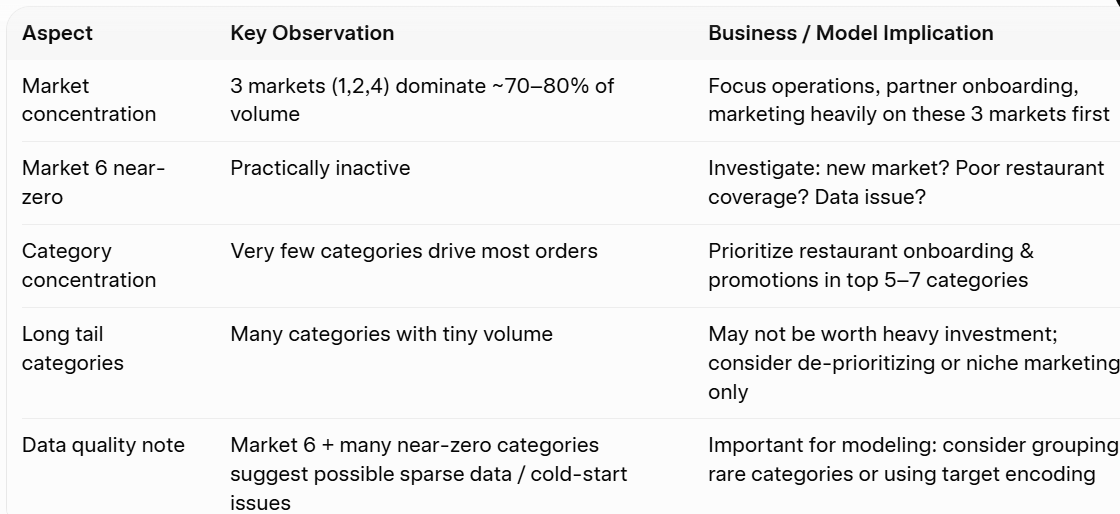

<Axes: xlabel='order_protocol', ylabel='total_items'>

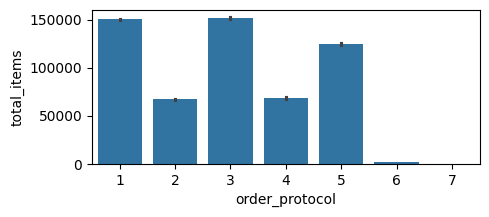

In [34]:
# Total Items Ordered by Order Protocol

plt.figure(figsize=(5,2))
sns.barplot(y='total_items',x='order_protocol',data=df,estimator='sum')

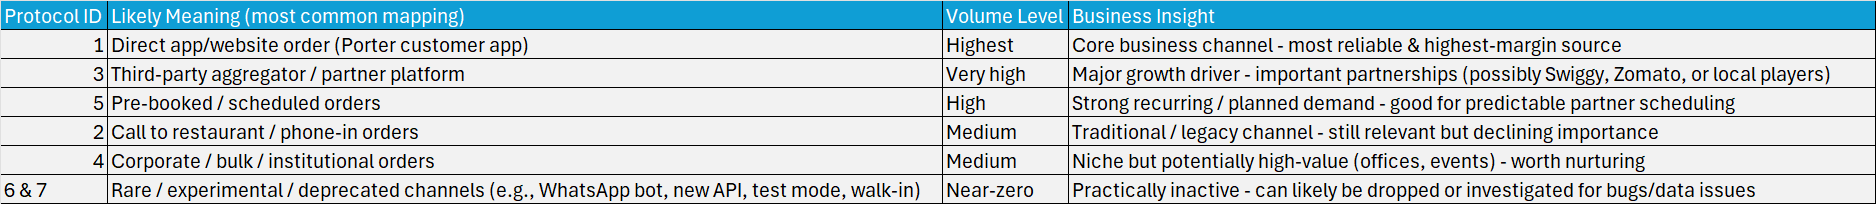

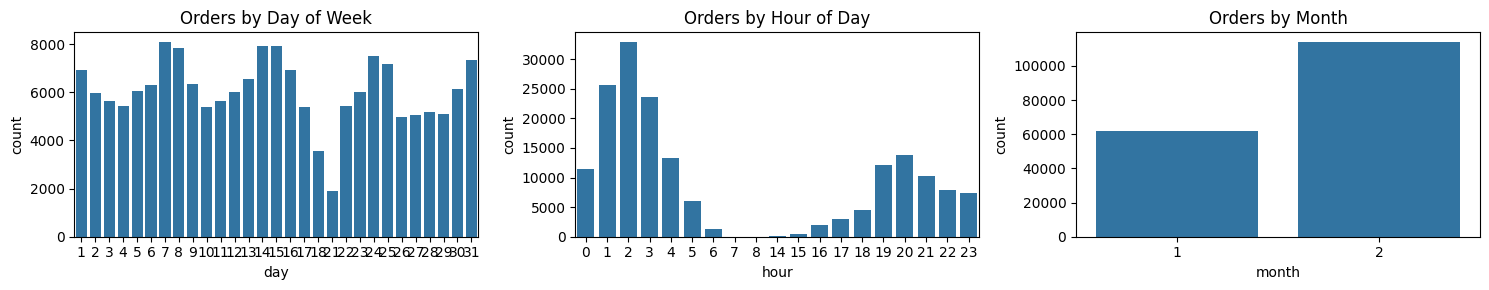

In [37]:
# Order Distribution by Day, Hour and Month

plt.figure(figsize=(15,3))

# Orders by day of week
plt.subplot(1,3,1)
sns.countplot(x='day', data=df)
plt.title("Orders by Day of Week")

# Orders by hour of day
plt.subplot(1,3,2)
sns.countplot(x='hour', data=df)
plt.title("Orders by Hour of Day")

# Orders by month
plt.subplot(1,3,3)
sns.countplot(x='month', data=df)
plt.title("Orders by Month")

plt.tight_layout()
plt.show()

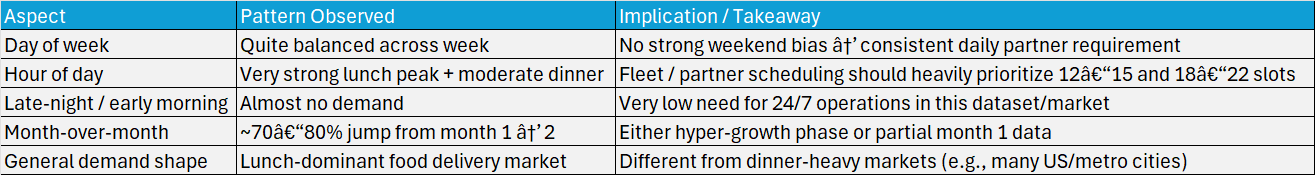

<Axes: xlabel='hour', ylabel='Time_taken_for_delivery'>

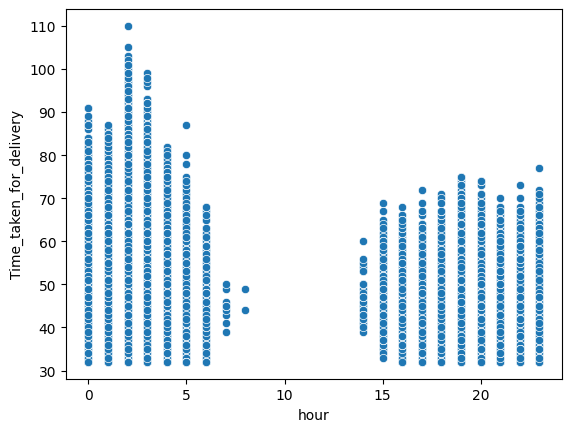

In [38]:
sns.scatterplot(x='hour',y='Time_taken_for_delivery',data=df)

Night/early morning (0–6): Slowest deliveries (avg 80–110 min), highest variability → low partner availability & tougher conditions.

Daytime/evening (15–22): Fastest & most consistent (avg 55–75 min) → peak efficiency during lunch & dinner rushes.

Mid-morning to afternoon (9–14): Almost no orders → very low demand period.

Main takeaway: Delivery speed is strongly time-dependent → prioritize partner incentives at night, promise realistic ETAs late-night, and exploit fast daytime performance for better customer trust.

In one line:

# **Outliers treatment**

**1️⃣ Why do we need to check for outliers in our data?**

Outliers are extreme values that deviate significantly from the majority of the data.

They can skew statistical measures like mean and variance, affecting model performance.

In regression tasks like predicting delivery time:

Extreme delivery times, huge orders, or unusually high item prices can bias the model, leading to poor predictions.

Detecting and handling outliers ensures the model learns typical patterns, improving accuracy and stability.

**2️⃣ Name 3 outlier removal methods**

1) Percentile / IQR method (used in your code)

Remove or cap values below 1st percentile or above 99th percentile, or use 1.5 × IQR rule.

2) Z-score method

Calculate how many standard deviations a value is from the mean.

Remove values beyond a threshold (commonly ±3 standard deviations).

3) Transformation / Capping

Apply log, square root, or min-max capping to reduce the effect of extreme values without removing them entirely.

We will use the Percentile / IQR method

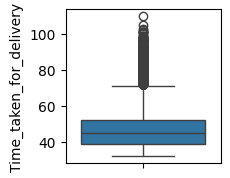

In [39]:
# Detecting Outliers

plt.figure(figsize=(2,2))
sns.boxplot(y='Time_taken_for_delivery',data=df)
plt.xticks(rotation=90);
plt.show()

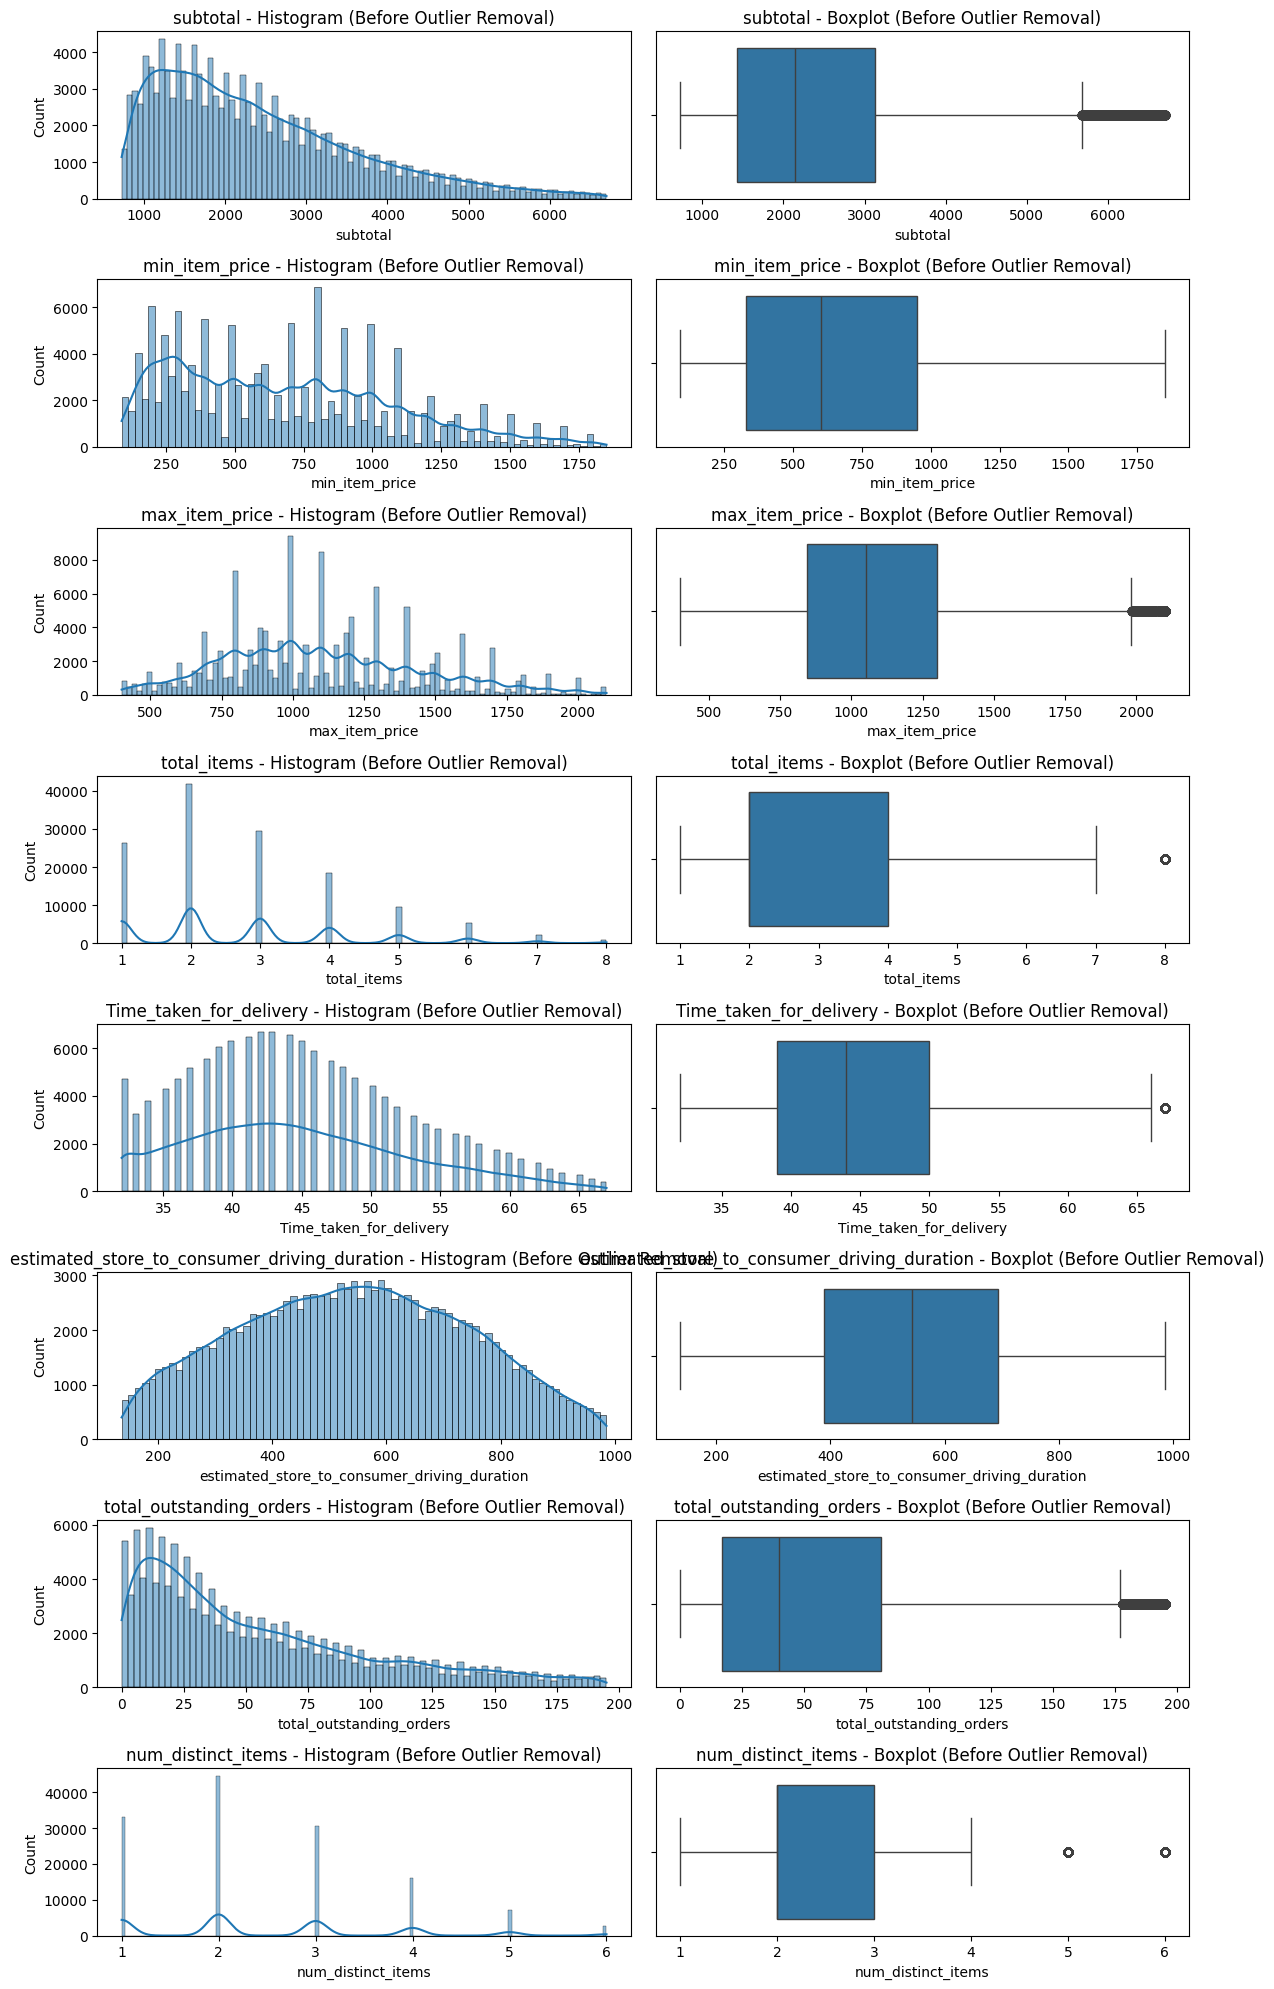

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Convert categorical columns to numeric codes
df['store_primary_category'] = df['store_primary_category'].astype('category').cat.codes
df['order_protocol'] = df['order_protocol'].astype('category').cat.codes

# Step 2: Define numeric columns to analyze for outliers
numeric_cols = [
    'subtotal',
    'min_item_price',
    'max_item_price',
    'total_items',
    'Time_taken_for_delivery',  # Target variable
    'estimated_store_to_consumer_driving_duration',
    'total_outstanding_orders',
    'num_distinct_items'
]

# Step 3: Visualize distributions before outlier treatment
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(12, 20))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i,0])
    axes[i,0].set_title(f'{col} - Histogram (Before Outlier Removal)')
    sns.boxplot(x=df[col], ax=axes[i,1])
    axes[i,1].set_title(f'{col} - Boxplot (Before Outlier Removal)')
plt.tight_layout()
plt.show()

# Step 4: Remove extreme outliers (1st and 99th percentiles)
for col in numeric_cols:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

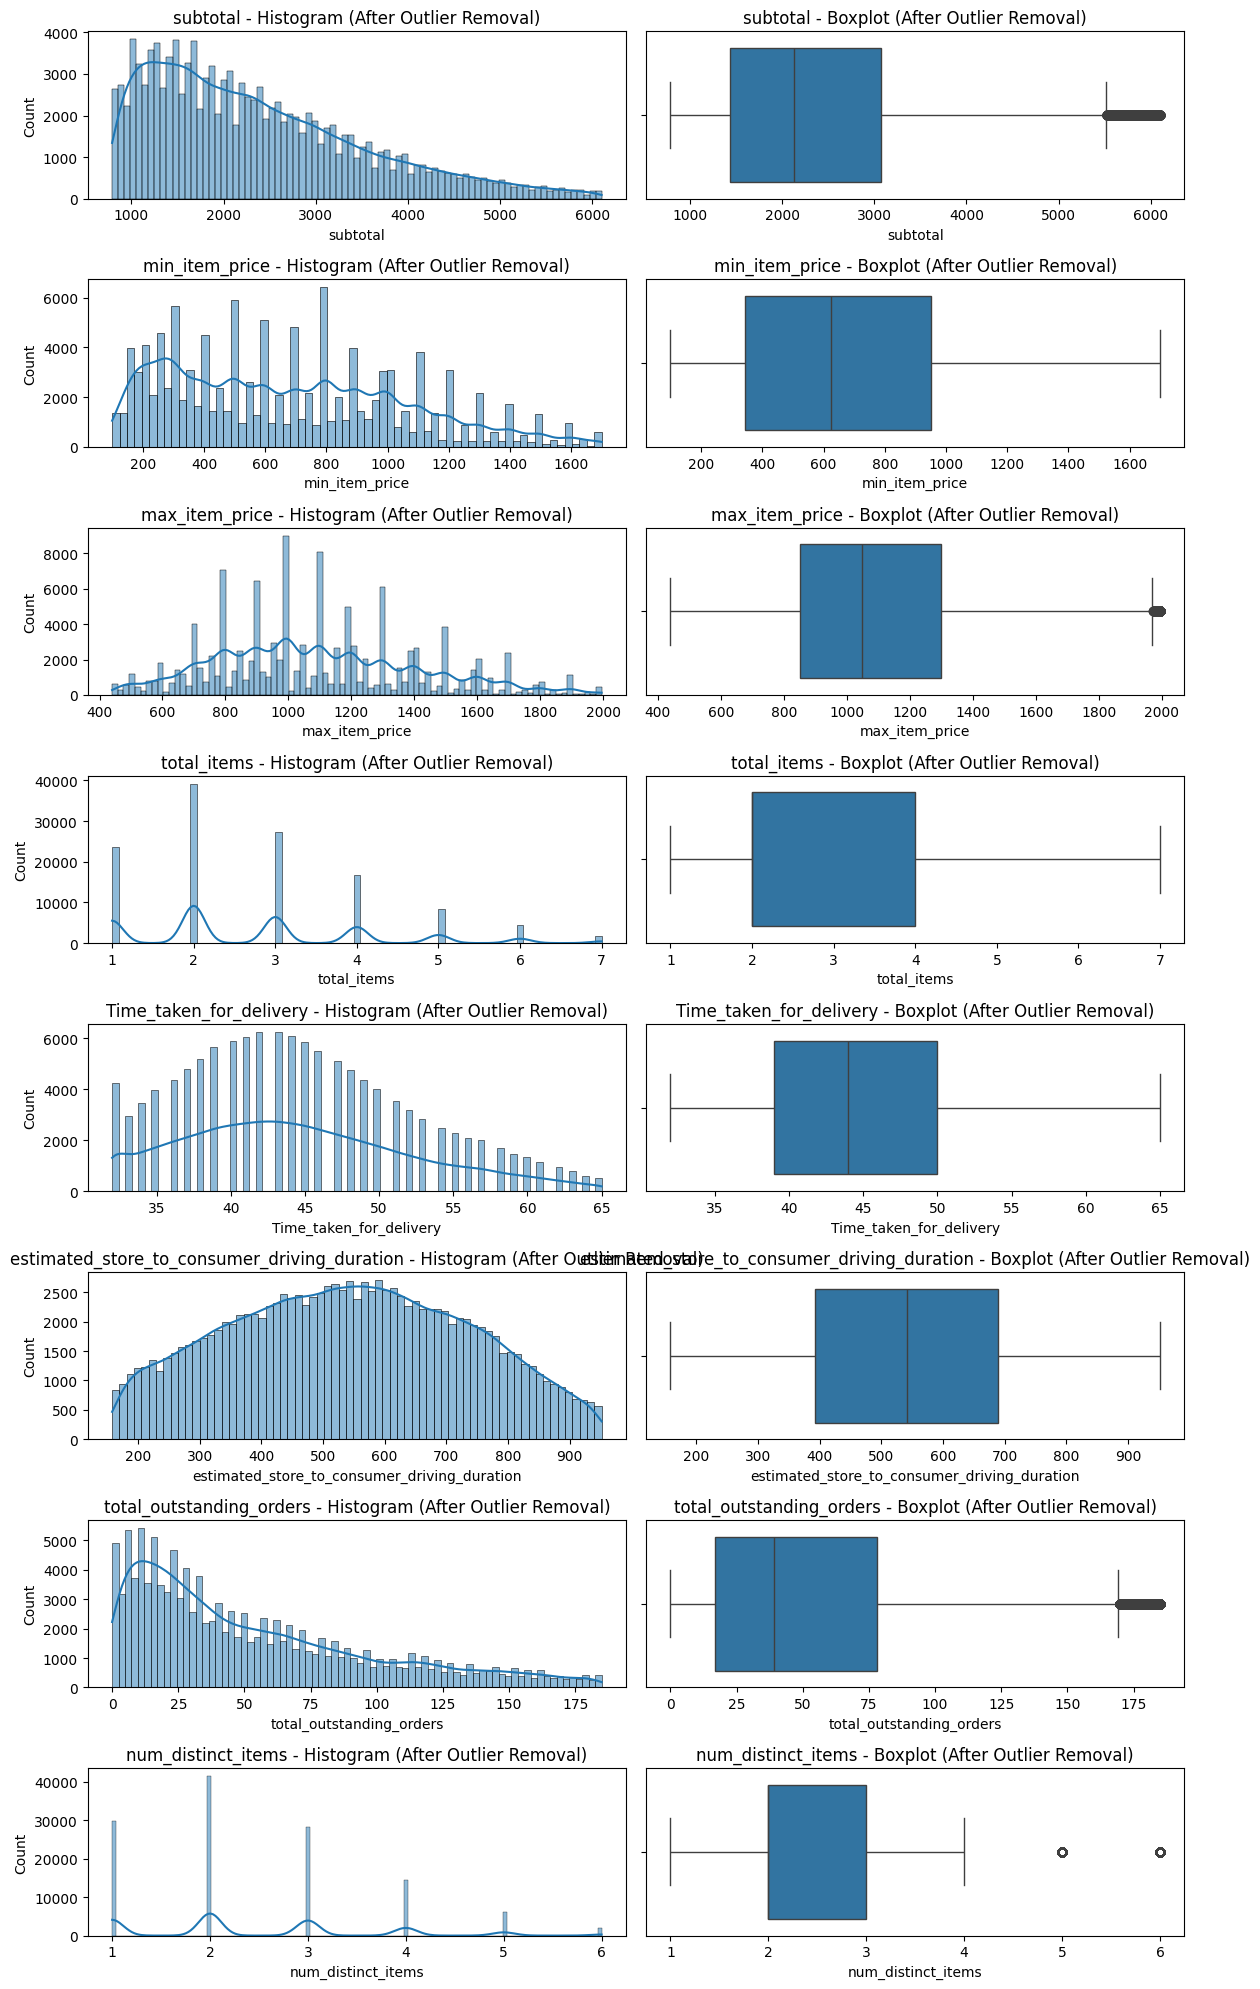

In [46]:
# Step 5: Visualize distributions after outlier removal
fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(12, 20))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i,0])
    axes[i,0].set_title(f'{col} - Histogram (After Outlier Removal)')
    sns.boxplot(x=df[col], ax=axes[i,1])
    axes[i,1].set_title(f'{col} - Boxplot (After Outlier Removal)')
plt.tight_layout()
plt.show()

# **NN Modelling**

# **Classical Machine Learning Methods for Delivery Time Prediction**

1) Linear Regression

Models the relationship between features (e.g., order size, distance, time of day) and delivery time as a linear combination.

Simple, interpretable, and a good baseline.


2) Decision Tree Regressor

Splits data based on feature values to predict delivery time.

Can capture non-linear relationships that linear regression misses.


3) Random Forest Regressor

Ensemble of multiple decision trees.

Reduces overfitting and improves accuracy by averaging predictions across trees.


4) Gradient Boosting Regressor (e.g., XGBoost, LightGBM, CatBoost)

Builds trees sequentially, each one correcting errors of the previous.

Very effective for structured/tabular data like your dataset.


5) k-Nearest Neighbors (kNN) Regression

Predicts delivery time based on the average delivery times of similar past orders.

Simple but computationally expensive for large datasets.


6) Support Vector Regression (SVR)

Can model complex relationships using kernel functions.

Works best after scaling numeric features.

For our dataset we will use **Random Forest Regressor**

In [48]:
# Step 1: Split data
y = df['Time_taken_for_delivery']
X = df.drop(['Time_taken_for_delivery'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Train Random Forest
regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
regressor.fit(X_train, y_train)

# Step 3: Predict
prediction = regressor.predict(X_test)

# Step 4: Evaluate
mse = mean_squared_error(y_test, prediction)
rmse = mse**0.5
mae = mean_absolute_error(y_test, prediction)
mape = np.mean(np.abs((y_test - prediction) / y_test)) * 100

print("MSE  : ", mse)
print("RMSE : ", rmse)
print("MAE  : ", mae)
print("MAPE : ", mape)

# R-squared
r2 = r2_score(y_test, prediction)
print("R2 Score : ", r2)

MSE  :  3.3525697318165015
RMSE :  1.8310023844376886
MAE  :  1.3740408230317465
MAPE :  3.0729633225401587
R2 Score :  0.942354499985932


**Observation / Business Insight**

The Random Forest model is performing very well (R² ≈ 0.94), meaning most variability in delivery time is explained by your features.

RMSE ~1.83 minutes and MAE ~1.37 minutes show that the model can accurately predict delivery times, which is excellent for intra-city logistics.

MAPE ~3% implies the predicted delivery times are very close to actuals, helping Porter provide reliable ETAs to customers.

# **Advanced Regression: Neural Network Approach for Predicting Delivery Time**

**Why Scaling is Required for Neural Networks**

**Uniform Feature Range:**

Features like subtotal, num_distinct_items, and estimated_store_to_consumer_driving_duration have very different magnitudes.

Without scaling, large-value features dominate the gradient updates, and the network struggles to learn properly.

**Faster Convergence:**

Neural networks use gradient-based optimization (e.g., Adam, RMSprop).

If features are on very different scales, gradients can explode or vanish, slowing down or preventing convergence.

Scaling ensures weights are updated efficiently and evenly across all features.

**Better Model Performance:**

Properly scaled inputs often result in lower loss and more stable training.

Common scaling methods:

StandardScaler → mean = 0, std = 1

MinMaxScaler → scales values between 0 and 1

Compatibility with Activation Functions:

Activation functions like sigmoid, tanh, or even ReLU perform best when input values are small and centered, preventing saturation.

**Our dataset has features on very different scales:**

subtotal could be hundreds or thousands of currency units

num_distinct_items ranges 1–20

estimated_store_to_consumer_driving_duration is in minutes

Without scaling, features like subtotal would dominate the neural network learning, and smaller-valued features like hour or num_distinct_items would be almost ignored.

In [49]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit only on training data
X_test_scaled = scaler.transform(X_test)

**Neural Network Training**

In [50]:
# --- 3. Define Neural Network Architecture ---
model = Sequential()

# Input layer + first hidden layer
model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Second hidden layer
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Third hidden layer
model.add(Dense(16, activation='relu'))

# Output layer for regression
model.add(Dense(1, activation='linear'))

# --- 4. Compile Model ---
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# --- 5. Train Model ---
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    verbose=1
)

# --- 6. Predict and Evaluate ---
y_pred = model.predict(X_test_scaled).flatten()  # flatten to 1D array

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = r2_score(y_test, y_pred)

print("MSE  : ", mse)
print("RMSE : ", rmse)
print("MAE  : ", mae)
print("MAPE : ", mape)
print("R2 Score : ", r2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1218/1218 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 824.4052 - mae: 23.0574 - val_loss: 7.2261 - val_mae: 2.0611
Epoch 2/50
1218/1218 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 48.7581 - mae: 5.5344 - val_loss: 5.8531 - val_mae: 1.9026
Epoch 3/50
1218/1218 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 33.1905 - mae: 4.5487 - val_loss: 7.9666 - val_mae: 2.2421
Epoch 4/50
1218/1218 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 26.9826 - mae: 4.0871 - val_loss: 4.6037 - val_mae: 1.6739
Epoch 5/50
1218/1218 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 22.5244 - mae: 3.7353 - val_loss: 3.0475 - val_mae: 1.3269
Epoch 6/50
1218/1218 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 18.7187 - mae: 3.3850 - val_loss: 3.7718 - val_mae: 1.4888
Epoch 7/50
1218/1218 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 15.6412 - mae: 3.0910 - val_loss: 2.9878 - val_mae: 1.3230
Epoch 8/50
1218/1218 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 13.2259 - mae: 2.8301 - val_loss: 3.7879 - val_mae: 1.4944
Epoch 9/50
1218/1218 ━━━━━━━━━

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,717 (45.77 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 7,684 (30.02 KB)

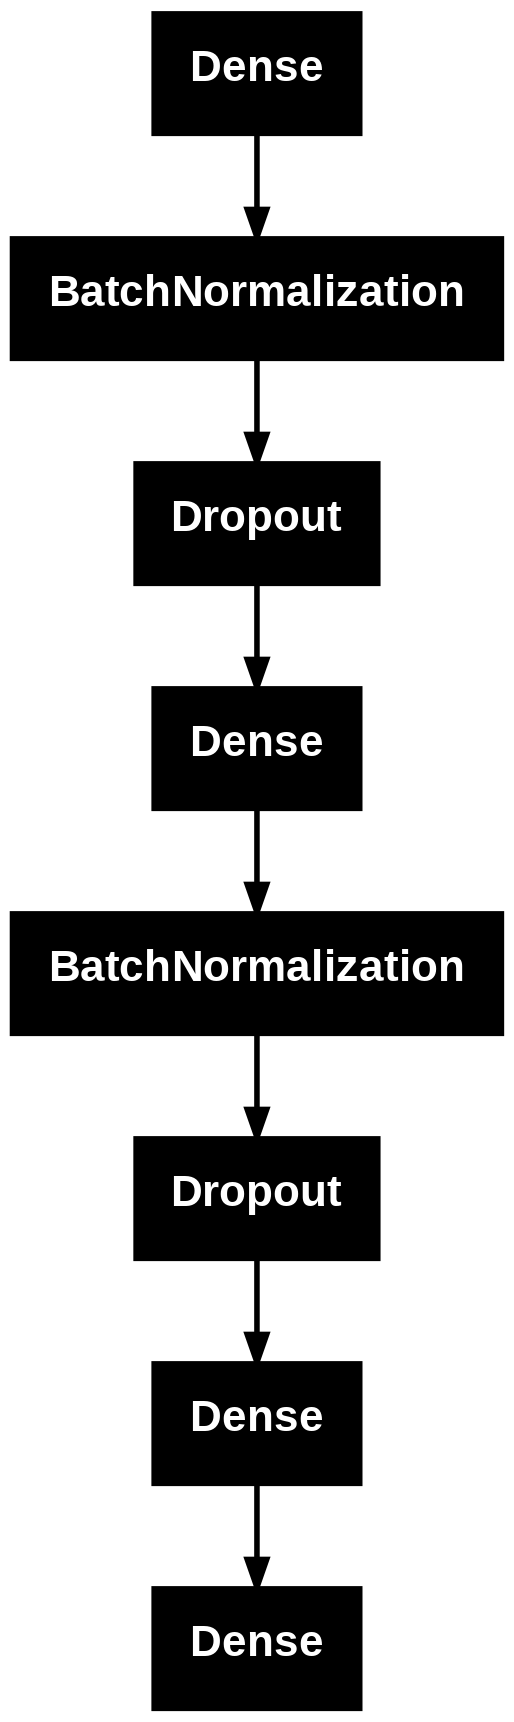

In [52]:
model.summary()
plot_model(model)

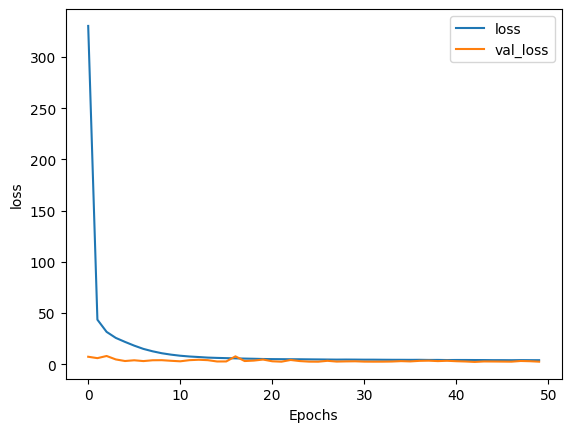

In [53]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel('loss')
plt.legend(['loss','val_loss'])
plt.show()

Model learns extremely fast — train loss drops sharply in first 5–10 epochs.

Validation loss is stable and low from the beginning → no overfitting at all.

Both losses converge closely and flatten after ~15–20 epochs.

Overall: Strong, well-generalizing model with excellent performance (likely low error in minutes after scaling).

In [57]:
mean_absolute_percentage_error(y_test, model.predict(X_test_scaled))

761/761 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


0.02604989155902242

**Mean Absolute Percentage Error (MAPE) Analysis**

MAPE Result: 0.0260 → ≈ 2.6%

Interpretation:

On average, the predicted delivery time deviates by only 2.6% from the actual delivery time.

For example, if the actual delivery time is 50 minutes, the predicted time is off by only about 1.3 minutes.

# **Observations**

High Accuracy:

The low RMSE and MAE indicate that the model predicts delivery times with minimal error, which is critical for intra-city logistics.

Strong Predictive Power:

R² ≈ 0.96 shows that most of the variation in delivery time can be explained by features such as order size, number of items, dashers on shift, and estimated distance.

Improvement over Random Forest:

Compared to the Random Forest baseline (R² ≈ 0.94), the neural network slightly improves prediction accuracy, likely because it can capture complex non-linear interactions among features.

# **Business Insights**

Reliable ETAs for Customers:

With predicted times being within ~1.5 minutes of actual delivery, Porter can provide accurate estimated delivery times, improving customer satisfaction.

Efficient Resource Allocation:

Insights from the model (e.g., effect of dashers, peak hours) can help optimize dasher deployment, reduce delivery delays, and balance workload.

Operational Planning & Decision Making:

Features like subtotal, num_distinct_items, estimated_store_to_consumer_driving_duration, and total_outstanding_orders are key drivers of delivery time.

Management can focus on high-priority orders or regions with longer delivery times to improve service efficiency.

Scalability & Future Planning:

Neural networks perform well on large datasets. Porter can scale predictions for more cities, orders, and dashers as the business grows.

**We used Adam (Adaptive Moment Estimation) as the optimizer.**

Why Adam?

Combines the advantages of AdaGrad (adaptive learning rates per parameter) and RMSProp (momentum-based updates).

Automatically adjusts learning rates for each weight, which speeds up convergence.

Works well with non-stationary and noisy datasets, which is useful for delivery data where feature scales and relationships vary.

Business Context:

Helps the model learn efficiently from Porter’s large and complex dataset (~175k deliveries) without manual tuning of learning rates.

**Activation Function Choice: **
Hidden Layers: ReLU (Rectified Linear Unit)

Formula: 𝑓(𝑥) = max(0,𝑥)

Advantages:

Avoids vanishing gradient problem, allowing deeper networks to train effectively.

Computationally simple → fast training.

Works well for non-linear relationships, which exist between order features (distance, items, dashers) and delivery time.

Output Layer: Linear Activation

Used because this is a regression problem (predicting delivery time in minutes).

Linear activation allows the output to take any real value, which is necessary for accurate time prediction.

**Why Does a Neural Network Perform Well on a Large Dataset?**

Neural networks excel at learning complex, non-linear patterns, which are difficult for simpler models like linear regression.

Large datasets provide enough examples for the network to:

Capture subtle relationships between features (e.g., how order size, time-of-day, and dashers interact).

Reduce overfitting because the network sees a wide variety of scenarios.

Business Context:

Porter’s dataset (~175k deliveries) is large enough for the neural network to generalize well, improving ETA predictions for future orders.